In [ ]:
# Workflow with llm 
# how langChain and langGraph work together
# pip install langChain

In [8]:
# LLM (model)
# pip install langchain-groq
# pip install python-dotenv
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
load_dotenv()
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=1.5,
)

p = "what is the capital of pakistan"
r = model.invoke(p)
print(r.content)

The capital of Pakistan is **Islamabad**.


In [9]:
# (1) now first make states with the help of class and class should be inherit TypedDict
from typing import TypedDict
class llm_state(TypedDict):
    question : str
    answer : str
     

In [10]:
# (2) now define function

def llm_work( state : llm_state ) -> llm_state:
    # now here first we extract question from state
    question =state['question']
    
    # now arite prompt for llm
    prompt = f" Answer the followi ng Question \n :{question}"
    
    # now invoke the model
    answer = model.invoke(prompt).content
    
    # now update the state 
    state['answer'] = answer
    return state

In [11]:
# (3) now make a Graph
from langgraph.graph import StateGraph
graph = StateGraph(llm_state)


In [12]:
# (4) now make nodes in graph and add function to node

graph.add_node("llm_node", llm_work)

In [13]:
# (5) now add edges between nodes
from langgraph.graph import START , END
graph.add_edge(START, "llm_node")
graph.add_edge('llm_node' , END)


In [15]:
# (6) now compile graph
workflow = graph.compile()

In [17]:
f_answer = workflow.invoke({'question' : "what is jamiat talaba e islam"})
print(f_answer)

{'question': 'what is jamiat talaba e islam', 'answer': '**Jamiat‑Talaba‑e‑Islam (JTI)** – often rendered in English as *The Islamic Students’ Association* – is the student wing of the **Jamaat‑e‑Islami (JI)**, one of Pakistan’s oldest and largest Islamist political parties.  \n\n---\n\n## 1. Historical Background  \n\n| Year | Event |\n|------|-------|\n| **1947** | Jamaat‑e‑Islami is founded by Maulana Maududi in British‑India. |\n| **1948‑49** | The idea of a student wing is conceived to mobilise university‑level youth. |\n| **1950** | JTI is formally launched on the campus of *Government College, Lahore* (later Government College University). |\n| **1960s‑70s** | Becomes an active participant in the anti‑Ayub and anti‑Zia movements, establishing a reputation as a disciplined “political campus” organization. |\n| **1990‑present** | Continues to operate on more than 250 campuses across Pakistan (public, private, and professional institutions) and has expanded to diaspora campuses in 

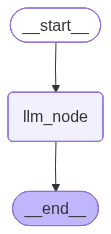

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())